24년도 코인데이터를 시각화하는 노트북
5% 올랐을 시 표시

In [3]:
# 1. 필요한 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

In [7]:
# 2. 데이터 불러오기
df = pd.read_csv("../data/filtered_BTC_data_2024.csv")

In [8]:
# 3. 날짜 컬럼을 datetime 형식으로 변환
df['캔들 기준 시각(UTC기준)'] = pd.to_datetime(df['캔들 기준 시각(UTC기준)'])

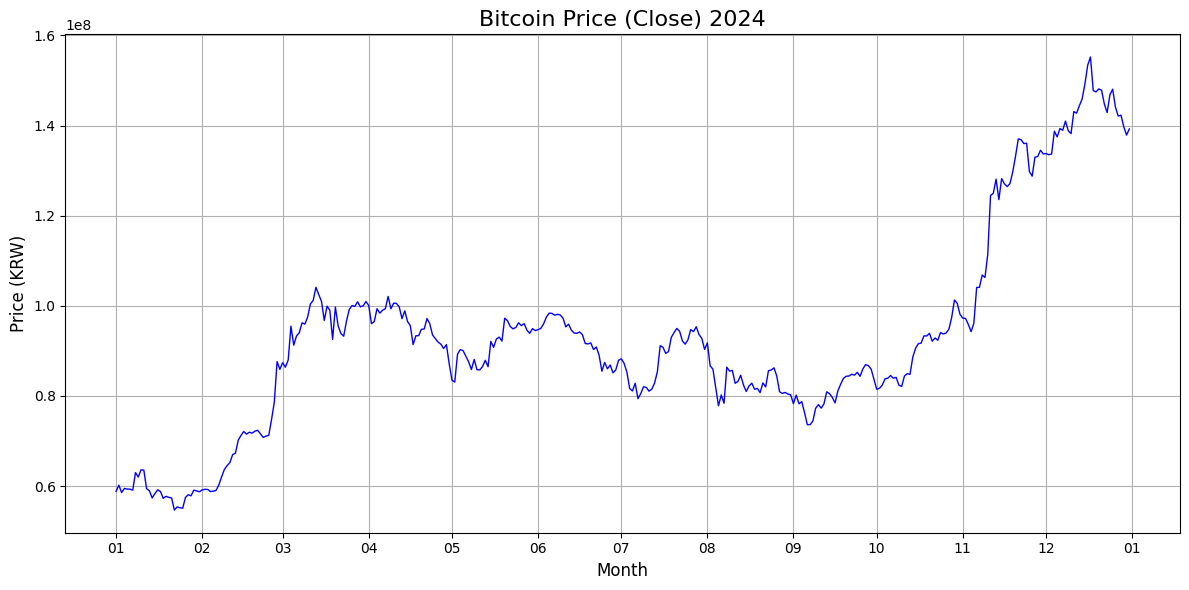

In [9]:
# 시계열 그래프 그리기 (종가 기준)
plt.figure(figsize=(12, 6))
plt.plot(df['캔들 기준 시각(UTC기준)'], df['종가'], color='blue', linewidth=1)

# 날짜 포맷 설정
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # 매월마다 표시
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m'))  # '09', '10', '11', '12' 형식

plt.title("Bitcoin Price (Close) 2024", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Price (KRW)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
threshold = 5
marked_df = df[df['전일 종가 대비 변화량의 절댓값'] >= threshold]

In [15]:
# 변화율 5% 이상인 날의 전체 행만 추출 (이미 marked_df에서 추출됨)
threshold = 5
marked_df = df[df['전일 종가 대비 변화량의 절댓값'] >= threshold]

# CSV 파일로 저장
output_path = "../data/btc_price_change_over_5percent.csv"
marked_df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"5% 이상 상승/하락한 날의 데이터를 '{output_path}'로 저장했습니다.")


5% 이상 상승/하락한 날의 데이터를 '../data/btc_price_change_over_5percent.csv'로 저장했습니다.


In [16]:
# matplotlib 한글 깨짐 방지
import platform

# 운영체제별 폰트 설정
if platform.system() == 'Darwin':  # macOS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':  # Windows
    plt.rc('font', family='Malgun Gothic')
else:  # Linux (colab 등)
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

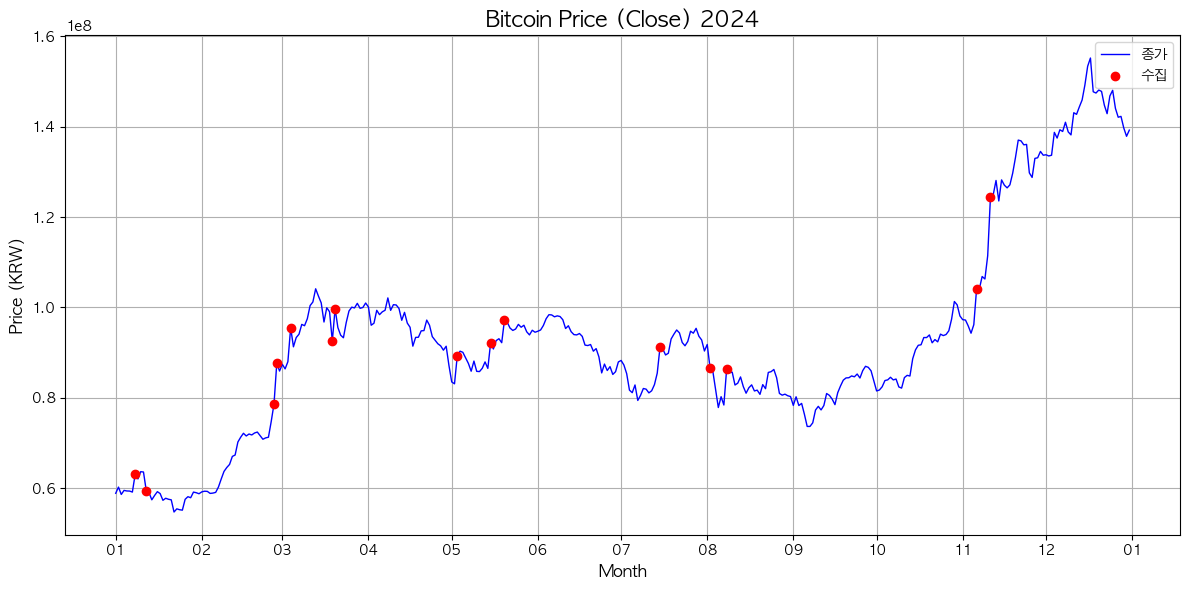

In [17]:
# 5. 시계열 그래프 그리기
plt.figure(figsize=(12, 6))
plt.plot(df['캔들 기준 시각(UTC기준)'], df['종가'], color='blue', linewidth=1, label='종가')

# 6. 마커 표시
plt.scatter(marked_df['캔들 기준 시각(UTC기준)'], marked_df['종가'], color='red', label='수집', zorder=5)

# 7. 날짜 포맷 설정
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m'))

plt.title("Bitcoin Price (Close) 2024", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Price (KRW)", fontsize=12)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()